### Evaluation Metrics for Classification

In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression

In [11]:
df = pd.read_csv('data.csv')

df.columns = df.columns.str.lower().str.replace(' ', '_')

categorical_columns = list(df.dtypes[df.dtypes == 'str'].index)

for col in categorical_columns:
    df[col] = df[col].str.lower().str.replace(' ', '_')
    
df.totalcharges = pd.to_numeric(df.totalcharges, errors='coerce')
df.totalcharges = df.totalcharges.fillna(0)

df.churn = (df.churn == 'yes').astype(int)

In [13]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

y_train = df_train.churn.values
y_val = df_val.churn.values
y_test = df_test.churn.values

del df_train['churn']
del df_val['churn']
del df_test['churn']

In [14]:
numerical = ['tenure', 'monthlycharges', 'totalcharges']

categorical = [
    'gender',
    'seniorcitizen',
    'partner',
    'dependents',
    'phoneservice',
    'multiplelines',
    'internetservice',
    'onlinesecurity',
    'onlinebackup',
    'deviceprotection',
    'techsupport',
    'streamingtv',
    'streamingmovies',
    'contract',
    'paperlessbilling',
    'paymentmethod',
]

In [16]:
dv = DictVectorizer(sparse=False)

train_dicts = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dicts)

model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",10000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 

In [17]:
val_dicts = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dicts)

y_pred = model.predict_proba(X_val)[:, 1]
churn_decision = (y_pred >= 0.5).astype(int)
(y_val == churn_decision).mean()

np.float64(0.8034066713981547)

#### Accuracy and Dummy Model

* Evaluate the model on different thresholds
* Check the accuracy of dummy baselines

In [18]:
len(y_val)

1409

In [19]:
(y_val == churn_decision).mean()

np.float64(0.8034066713981547)

In [20]:
from sklearn.metrics import accuracy_score

In [21]:
accuracy_score(y_val, y_pred >= 0.5)

0.8034066713981547

In [23]:
thresholds = np.linspace(0, 1, 21)

scores = []
for t in thresholds:
    churn_decision = (y_pred >= t).astype(int)
    score = accuracy_score(y_val, churn_decision)
    print('%.2f %.3f' % (t, score))
    scores.append(score)

0.00 0.274
0.05 0.513
0.10 0.608
0.15 0.662
0.20 0.703
0.25 0.735
0.30 0.759
0.35 0.764
0.40 0.781
0.45 0.791
0.50 0.803
0.55 0.802
0.60 0.796
0.65 0.789
0.70 0.766
0.75 0.742
0.80 0.729
0.85 0.726
0.90 0.726
0.95 0.726
1.00 0.726


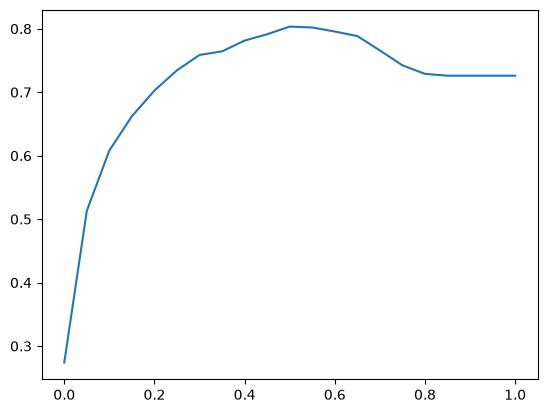

In [24]:
plt.plot(thresholds, scores)

In [25]:
from collections import Counter

Counter(y_pred >= 1.0)

Counter({np.False_: 1409})

In [27]:
# If the model predicts that all customers will churn
1 - y_val.mean()

np.float64(0.7260468417317246)

#### Confusion Table
* Different types of errors and correct decisions
* Arranging them in a table

In [30]:
actual_positive = (y_val == 1)
actual_negative = (y_val == 0)

In [31]:
t = 0.5
predicted_positive = (y_pred >= t)
predicted_negative = (y_pred < t)

In [32]:
tp = (predicted_positive & actual_positive).sum()  # true positive
tn = (predicted_negative & actual_negative).sum()  # true negative
fp = (predicted_positive & actual_negative).sum()  # false positive
fn = (predicted_negative & actual_positive).sum()  # false negative

In [33]:
confusion_matrix = np.array([[tn, fp],
                             [fn, tp]])
confusion_matrix

array([[920, 103],
       [174, 212]])

In [34]:
(confusion_matrix / confusion_matrix.sum()).round(2)

array([[0.65, 0.07],
       [0.12, 0.15]])

#### Precision and Recall

In [35]:
p = tp / (tp + fp)
p

np.float64(0.6730158730158731)

In [36]:
r = tp / (tp + fn)
r

np.float64(0.5492227979274611)

#### ROC Curves

##### TPR and FRP

In [37]:
# TPR : True Positive Rate
tpr = tp / (tp + fn)
tpr

np.float64(0.5492227979274611)

In [38]:
# FPR : False Positive Rate
fpr = fp / (fp + tn)
fpr

np.float64(0.10068426197458455)

In [39]:
scores = []

thresholds = np.linspace(0, 1, 101)

for t in thresholds:
    actual_positive = (y_val == 1)
    actual_negative = (y_val == 0)
    
    predicted_positive = (y_pred >= t)
    predicted_negative = (y_pred < t)
    
    tp = (predicted_positive & actual_positive).sum()  # true positive
    tn = (predicted_negative & actual_negative).sum()  # true negative
    fp = (predicted_positive & actual_negative).sum()  # false positive
    fn = (predicted_negative & actual_positive).sum()  # false negative
    
    scores.append((t, tp, fp, fn, tn))

In [40]:
columns = ['threshold', 'tp', 'fp', 'fn', 'tn']
df_scores = pd.DataFrame(scores, columns=columns)

df_scores["tpr"] = df_scores.tp / (df_scores.tp + df_scores.fn)
df_scores["fpr"] = df_scores.fp / (df_scores.fp + df_scores.tn)

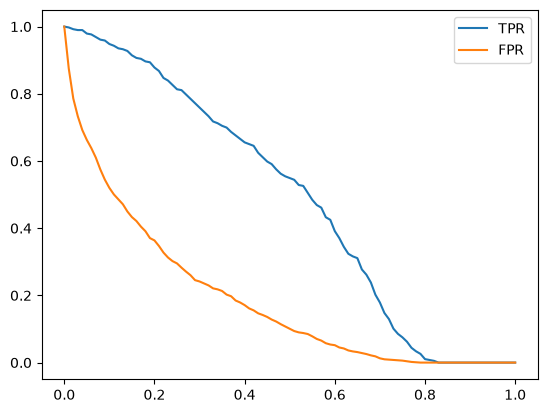

In [42]:
plt.plot(df_scores.threshold, df_scores.tpr, label='TPR')
plt.plot(df_scores.threshold, df_scores.fpr, label='FPR')
plt.legend()

#### Random Model

In [44]:
np.random.seed(1)
y_rand = np.random.uniform(0 , 1, size=len(y_val))

In [45]:
((y_rand >= 0.5) == y_val).mean()

np.float64(0.5017743080198722)

In [46]:
def tpr_fpr_dataframe(y_val, y_pred):
    scores = []
    thresholds = np.linspace(0, 1, 101)

    for t in thresholds:
        actual_positive = (y_val == 1)
        actual_negative = (y_val == 0)
        
        predicted_positive = (y_pred >= t)
        predicted_negative = (y_pred < t)
        
        tp = (predicted_positive & actual_positive).sum()  # true positive
        tn = (predicted_negative & actual_negative).sum()  # true negative
        fp = (predicted_positive & actual_negative).sum()  # false positive
        fn = (predicted_negative & actual_positive).sum()  # false negative
        
        scores.append((t, tp, fp, fn, tn))

    columns = ['threshold', 'tp', 'fp', 'fn', 'tn']
    df_scores = pd.DataFrame(scores, columns=columns)

    df_scores["tpr"] = df_scores.tp / (df_scores.tp + df_scores.fn)
    df_scores["fpr"] = df_scores.fp / (df_scores.fp + df_scores.tn)
    
    return df_scores

In [47]:
df_rand = tpr_fpr_dataframe(y_val, y_rand)

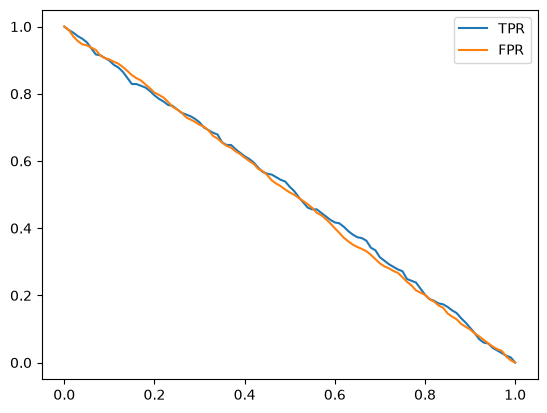

In [48]:
plt.plot(df_rand.threshold, df_rand.tpr, label='TPR')
plt.plot(df_rand.threshold, df_rand.fpr, label='FPR')
plt.legend()

#### Ideal Model

In [49]:
num_neg = (y_val == 0).sum()
num_pos = (y_val == 1).sum()
num_neg, num_pos

(np.int64(1023), np.int64(386))

In [51]:
y_ideal = np.repeat([0, 1], [num_neg, num_pos])
y_ideal_pred = np.linspace(0, 1, len(y_val))

In [52]:
1 - y_val.mean()

np.float64(0.7260468417317246)

In [53]:
accuracy_score(y_ideal, y_ideal_pred >= 0.726)

1.0

In [54]:
df_ideal = tpr_fpr_dataframe(y_ideal, y_ideal_pred)
df_ideal[::10]

,threshold,tp,fp,fn,tn,tpr,fpr
0,0.0,386,1023,0,0,1.000000,1.000000
10,0.1,386,882,0,141,1.000000,0.862170
20,0.2,386,741,0,282,1.000000,0.724340
30,0.3,386,600,0,423,1.000000,0.586510
40,0.4,386,459,0,564,1.000000,0.448680
50,0.5,386,319,0,704,1.000000,0.311828
60,0.6,386,178,0,845,1.000000,0.173998
70,0.7,386,37,0,986,1.000000,0.036168
80,0.8,282,0,104,1023,0.730570,0.000000
90,0.9,141,0,245,1023,0.365285,0.000000


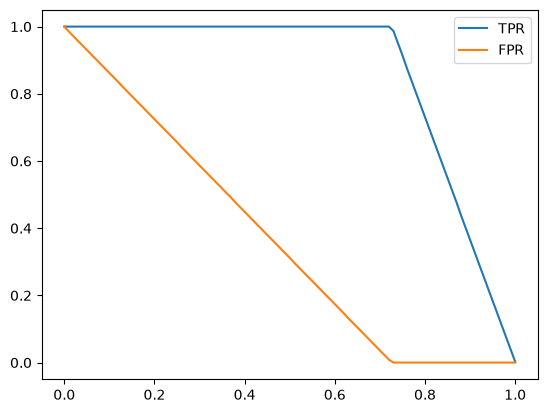

In [55]:
plt.plot(df_ideal.threshold, df_ideal.tpr, label='TPR')
plt.plot(df_ideal.threshold, df_ideal.fpr, label='FPR')
plt.legend()

#### Putting everything together

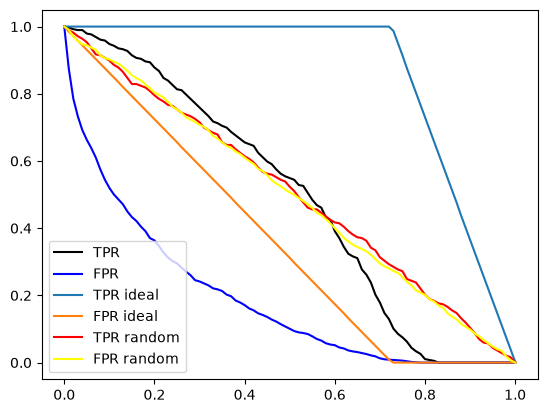

In [56]:
plt.plot(df_scores.threshold, df_scores.tpr, label='TPR', color='black')
plt.plot(df_scores.threshold, df_scores.fpr, label='FPR', color='blue')

plt.plot(df_ideal.threshold, df_ideal.tpr, label='TPR ideal')
plt.plot(df_ideal.threshold, df_ideal.fpr, label='FPR ideal')

plt.plot(df_rand.threshold, df_rand.tpr, label='TPR random', color='red')
plt.plot(df_rand.threshold, df_rand.fpr, label='FPR random', color='yellow')

plt.legend()

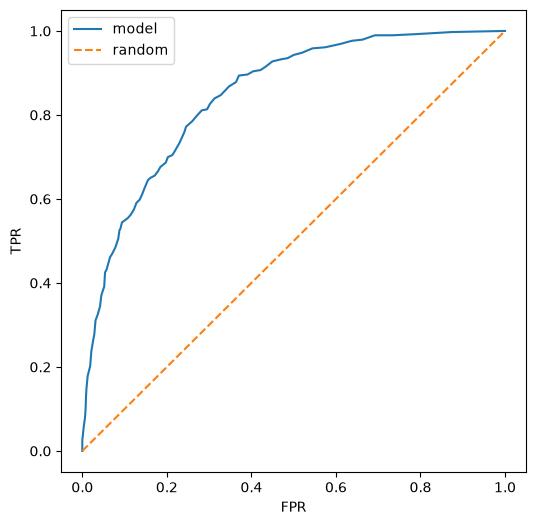

In [57]:
plt.figure(figsize=(6, 6))

plt.plot(df_scores.fpr, df_scores.tpr, label='model')
plt.plot([0, 1], [0, 1], label='random', linestyle='--')

plt.xlabel('FPR')
plt.ylabel('TPR')

plt.legend()

In [58]:
from sklearn.metrics import roc_curve

In [59]:
fpr, tpr, thresholds = roc_curve(y_val, y_pred)

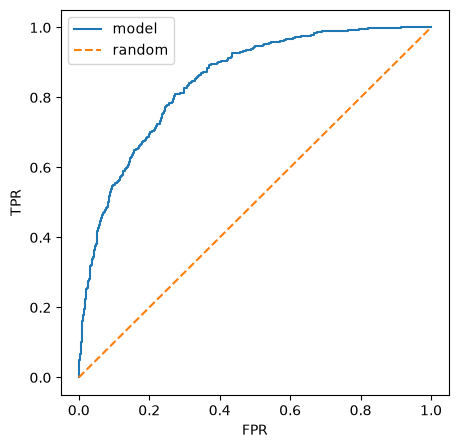

In [61]:
plt.figure(figsize=(5, 5))

plt.plot(fpr, tpr, label='model')
plt.plot([0, 1], [0, 1], label='random', linestyle='--')

plt.xlabel('FPR')
plt.ylabel('TPR')

plt.legend()

#### ROC AUC
* Area under the ROC curve - useful metric
* Interpretation of AUC

In [62]:
from sklearn.metrics import auc

In [64]:
auc(fpr, tpr)

0.846286701208981

In [65]:
auc(df_scores.fpr, df_scores.tpr)

0.8460309260075264

In [66]:
auc(df_ideal.fpr, df_ideal.tpr)

0.9999430203759136

In [67]:
fpr, tpr, thresholds = roc_curve(y_val, y_pred)
auc(fpr, tpr)

0.846286701208981

In [68]:
from sklearn.metrics import roc_auc_score

In [69]:
roc_auc_score(y_val, y_pred)

0.846286701208981

In [73]:
# AUC Simulation:

neg = y_pred[y_val == 0]
pos = y_pred[y_val == 1]

In [74]:
import random

In [75]:
n = 100000
successes = 0

for i in range(n):
    pos_ind = random.randint(0, len(pos) - 1)
    neg_ind = random.randint(0, len(neg) - 1)
    
    if pos[pos_ind] > neg[neg_ind]:
        successes += 1
        
successes / n

0.8468

In [76]:
n = 50000

np.random.seed(1)
pos_ind = np.random.randint(0, len(pos), size=n)
neg_ind = np.random.randint(0, len(neg), size=n)

(pos[pos_ind] > neg[neg_ind]).mean()

np.float64(0.84902)

#### Cross-Validation
* Evaluating the same model on different subsets of data
* Getting the average prediction and the spread within predictions

In [77]:
def train(df_train, y_train, C=1.0):
    dv = DictVectorizer(sparse=False)
    train_dicts = df_train[categorical + numerical].to_dict(orient='records')
    X_train = dv.fit_transform(train_dicts)

    model = LogisticRegression(C=C, max_iter=10000)
    model.fit(X_train, y_train)
    
    return dv, model

In [78]:
dv, model = train(df_train, y_train, C=0.001)

In [79]:
def predict(df, dv, model):
    dicts = df[categorical + numerical].to_dict(orient='records')
    X = dv.transform(dicts)
    y_pred = model.predict_proba(X)[:, 1]
    
    return y_pred

In [80]:
y_pred = predict(df_val, dv, model)

In [81]:
from sklearn.model_selection import KFold

In [83]:
from tqdm.auto import tqdm

In [84]:
n_splits = 5

for C in tqdm([0.001, 0.01, 0.1, 0.5, 1, 5, 10]):
    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=1)
    
    scores = []
    
    for train_idx, val_idx in kfold.split(df_full_train):
        df_train = df_full_train.iloc[train_idx]
        df_val = df_full_train.iloc[val_idx]
        
        y_train = df_train.churn.values
        y_val = df_val.churn.values
        
        dv, model = train(df_train, y_train, C=C)
        y_pred = predict(df_val, dv, model)
        
        auc_score = roc_auc_score(y_val, y_pred)
        scores.append(auc_score)
        
    print('C=%s %.3f +- %.3f' % (C, np.mean(scores), np.std(scores)))

 14%|█▍        | 1/7 [00:01<00:06,  1.07s/it]

C=0.001 0.825 +- 0.009


 29%|██▊       | 2/7 [00:03<00:07,  1.58s/it]

C=0.01 0.840 +- 0.008


 43%|████▎     | 3/7 [00:07<00:10,  2.72s/it]

C=0.1 0.842 +- 0.007


 57%|█████▋    | 4/7 [00:09<00:07,  2.51s/it]

C=0.5 0.842 +- 0.007


 71%|███████▏  | 5/7 [00:11<00:05,  2.57s/it]

C=1 0.842 +- 0.007


 86%|████████▌ | 6/7 [00:15<00:03,  3.03s/it]

C=5 0.842 +- 0.007


100%|██████████| 7/7 [00:18<00:00,  2.70s/it]

C=10 0.842 +- 0.007


In [85]:
scores

[0.8439175451955006,
 0.8447618692888359,
 0.8333172787477423,
 0.8348048698599475,
 0.8517500235323648]

In [86]:
dv, model = train(df_full_train, df_full_train.churn.values, C=1.0)
y_pred = predict(df_test, dv, model)

auc = roc_auc_score(y_test, y_pred)
auc

0.8583517501381259